# OpenMC transport model for a concentric annular fuel model (i.e like Missouri Research Reactor)

This notebook mirrors the workflow in frm2_nat.ipynb, but replaces the involute fuel plates with a concentric annular layout. A critical configuration with natural uranium is modeled with openmc and then ran to find K_eff as well as flux, fission and entropy tallies.

## Models

The reference case below uses {ring_count} concentric fuel annuli with {ring_thickness} fuel thickness.

In [3]:
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc

import fuel_element
import concentric_fuel
import reactor_geometry
import build_simulation
from ploting import plot_reactor_preview, resolve_openmc_exec, show_statepoint_diagnostics

importlib.reload(fuel_element)
importlib.reload(concentric_fuel)
importlib.reload(reactor_geometry)
importlib.reload(build_simulation)

from concentric_fuel import (
    ConcentricElementParameters,
    build_parameter_report,
    quick_layout_plot,
    validate_parameters,
 )
from reactor_geometry import ReactorTankParameters, validate_reactor_tanks

CONCENTRIC_FUEL_PARAMETERS = ConcentricElementParameters(
    ring_count=7,
    ring_thickness_cm=0.5,
    coolant_gap_cm=7.0,
    inner_radius_cm=4.5,
    outer_radius_cm=50.0,
    control_rod_radius_cm=4.0,
    h_active_cm=300.0,
    lower_plenum_cm=50.0,
    upper_plenum_cm=50.0,
    fuel_density_g_per_cm3=12.2,
    fuel_enrichment_wt_pct=0.7198,
 )

REACTOR_TANK_PARAMETERS = ReactorTankParameters(
    d2o_tank_radius_cm=250.0,
    h2o_tank_radius_cm=500.0, 
    h_d2o_tank_cm=600.0,
    h_h2o_tank_cm=1000.0, #700
 )

validate_parameters(CONCENTRIC_FUEL_PARAMETERS)
validate_reactor_tanks(CONCENTRIC_FUEL_PARAMETERS, REACTOR_TANK_PARAMETERS)

GEOMETRY = build_parameter_report(CONCENTRIC_FUEL_PARAMETERS)
GEOMETRY.update(REACTOR_TANK_PARAMETERS.to_geometry_dict())

GLOBAL_MESH_SHAPE = (160, 160)
FUEL_MESH_SHAPE = (220, 220)
DEFAULT_OPENMC_THREADS = os.cpu_count() or 1
OPENMC_THREADS = int(os.environ.get("OPENMC_THREADS", DEFAULT_OPENMC_THREADS))
OPENMC_EXEC = resolve_openmc_exec()

RUN_DIR = Path("build") / "concentric"
RUN_DIR.mkdir(parents=True, exist_ok=True)

GEOMETRY_REPORT = {
    "fuel_element": build_parameter_report(CONCENTRIC_FUEL_PARAMETERS),
    "reactor_tanks": REACTOR_TANK_PARAMETERS.to_geometry_dict(),
    "openmc_threads": OPENMC_THREADS,
    "openmc_exec": OPENMC_EXEC,
}
GEOMETRY_REPORT

{'fuel_element': {'ring_count': 7,
  'ring_thickness_cm': 0.5,
  'coolant_gap_cm': 7.0,
  'inner_radius_cm': 4.5,
  'outer_radius_cm': 50.0,
  'control_rod_radius_cm': 4.0,
  'h_active_cm': 300.0,
  'lower_plenum_cm': 50.0,
  'upper_plenum_cm': 50.0,
  'fuel_density_g_per_cm3': 12.2,
  'fuel_enrichment_wt_pct': 0.7198,
  'radial_span_cm': 45.5,
  'edge_gap_cm': 0.0,
  'h_total_cm': 400.0,
  'first_ring_inner_radius_cm': 4.5,
  'last_ring_outer_radius_cm': 50.0,
  'uranium_area_fraction': 0.07692307692307693,
  'uranium_volume_cm3': 179777.6396016759,
  'uranium_mass_kg': 2193.287203140446},
 'reactor_tanks': {'d2o_tank_radius_cm': 250.0,
  'h2o_tank_radius_cm': 500.0,
  'h_d2o_tank_cm': 600.0,
  'h_h2o_tank_cm': 1000.0,
  'h_total_cm': 1000.0},
 'openmc_threads': 19,
 'openmc_exec': '/home/pablo/miniconda3/envs/openmc/bin/openmc'}

{'ring_count': 7, 'ring_thickness_cm': 0.5, 'coolant_gap_cm': 7.0, 'inner_radius_cm': 4.5, 'outer_radius_cm': 50.0, 'control_rod_radius_cm': 4.0, 'h_active_cm': 300.0, 'lower_plenum_cm': 50.0, 'upper_plenum_cm': 50.0, 'fuel_density_g_per_cm3': 12.2, 'fuel_enrichment_wt_pct': 0.7198, 'radial_span_cm': 45.5, 'edge_gap_cm': 0.0, 'h_total_cm': 400.0, 'first_ring_inner_radius_cm': 4.5, 'last_ring_outer_radius_cm': 50.0, 'uranium_area_fraction': 0.07692307692307693, 'uranium_volume_cm3': 179777.6396016759, 'uranium_mass_kg': 2193.287203140446}


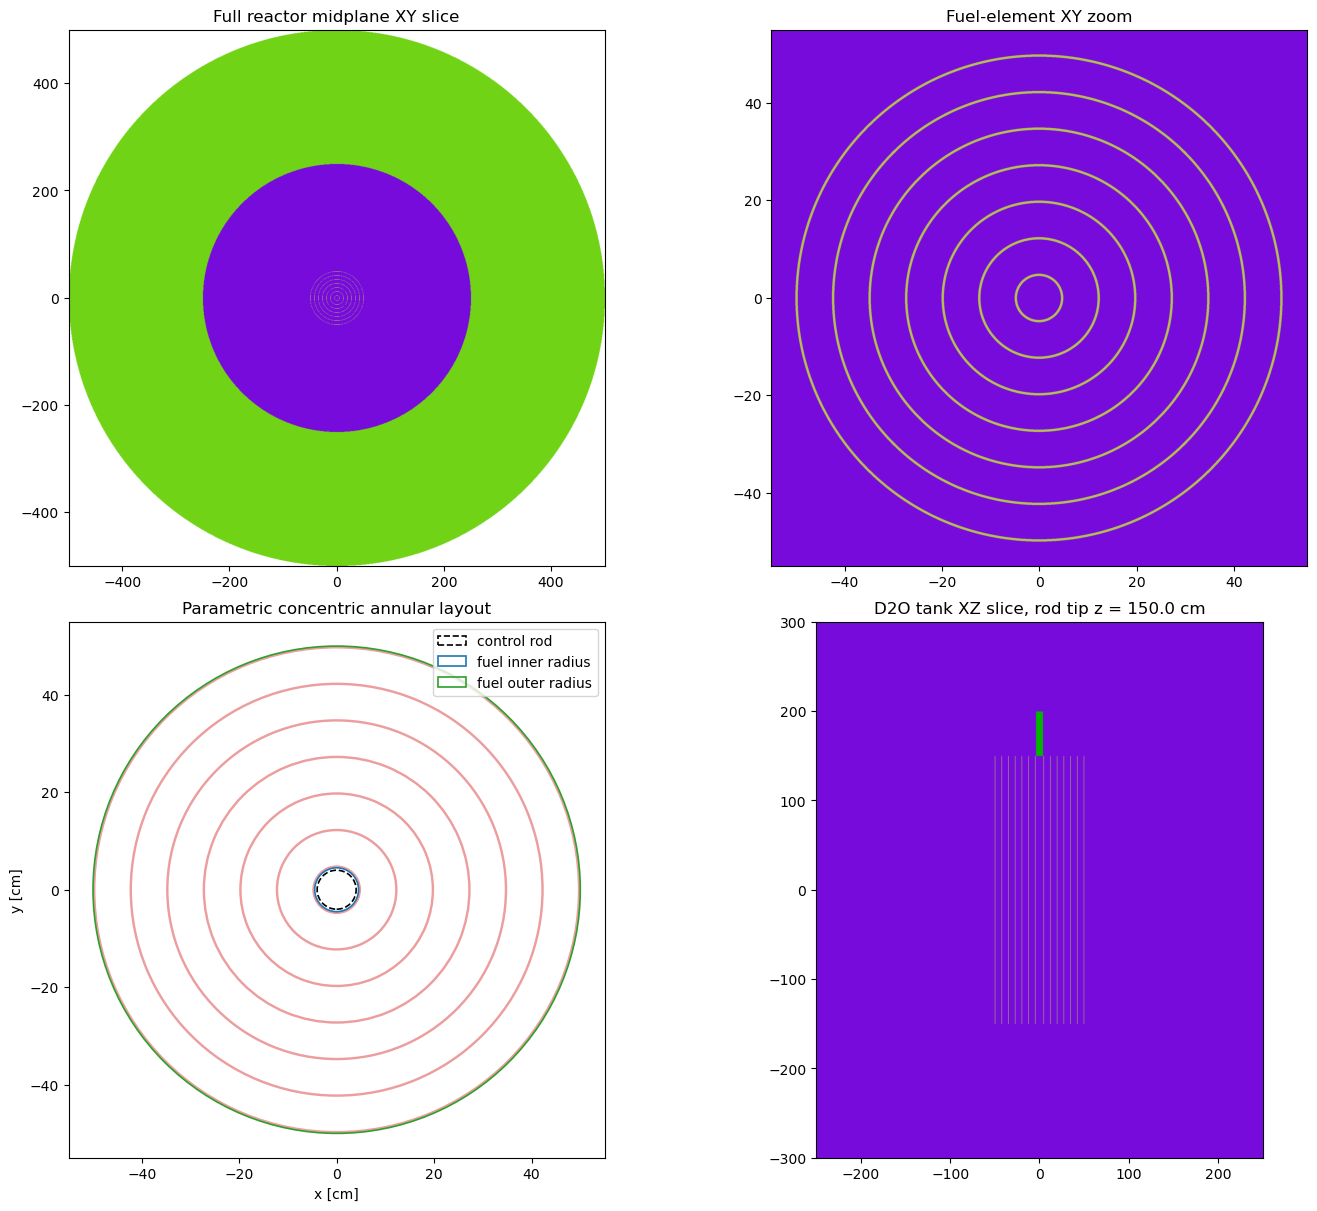

In [9]:
preview_model, preview_metadata = build_simulation.build_eigenvalue_model(
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    rod_insertion=0.0,
    particles=2000,
    batches=1,
    inactive=0,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
)

plot_reactor_preview(
    preview_model,
    preview_metadata,
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    quick_layout_plot=quick_layout_plot,
    layout_title="Parametric concentric annular layout",
)
print(build_parameter_report(CONCENTRIC_FUEL_PARAMETERS))
plt.show()

In [10]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.0
    reference_model, reference_metadata = build_simulation.build_eigenvalue_model(
        CONCENTRIC_FUEL_PARAMETERS,
        REACTOR_TANK_PARAMETERS,
        rod_insertion=reference_insertion,
        particles=20000,
        batches=100,
        inactive=10,
        global_mesh_shape=GLOBAL_MESH_SHAPE,
        fuel_mesh_shape=FUEL_MESH_SHAPE,
    )
    statepoint_path = reference_model.run(
        cwd=RUN_DIR,
        threads=OPENMC_THREADS,
        openmc_exec=OPENMC_EXEC,
        export_model_xml=True,
    )
    print(f"OpenMC run finished: {statepoint_path}")
    print(f"model.xml written to {RUN_DIR / 'model.xml'}")
    if reference_metadata["tally_names"]:
        print(f"Tallies recorded: {reference_metadata['tally_names']}")
    else:
        print("No mesh tallies were attached to this run, so this is a faster k_eff-only calculation.")
else:
    statepoint_path = None
    reference_metadata = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Run Diagnostics and Tallies

This cell now reports the Shannon entropy history for the fission source so you can judge whether the inactive batches were sufficient before trusting the final k_eff.

The mesh plotting section still stays dormant unless the run above was executed with mesh tallies enabled by passing a non-None mesh shape to `build_eigenvalue_model`. The diagnostic meshes are full-azimuth cylindrical r-z tallies, so the global map covers the complete reactor radius and height instead of sampling a thin Cartesian slice.

k_eff = 1.001079 +/- 0.000593
reactivity = 107.8 pcm
entropy mesh shape = (7, 7, 21)
final Shannon entropy = 9.771204
entropy spread over last 10 active batches = 0.013001


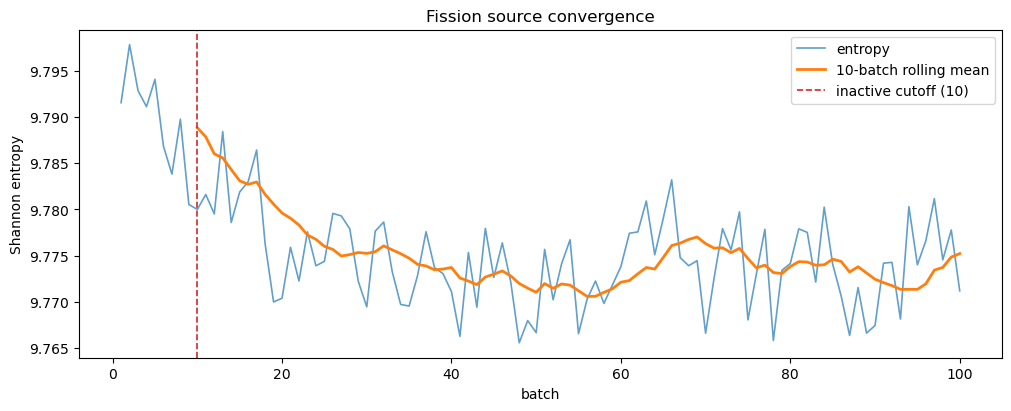

full reconstructed extent: x=[-500.0, 500.0] cm, z=[-500.0, 500.0] cm
global-mesh histories per bin: 70.312
flux nonzero fraction: 0.352
fission nonzero fraction: 0.017


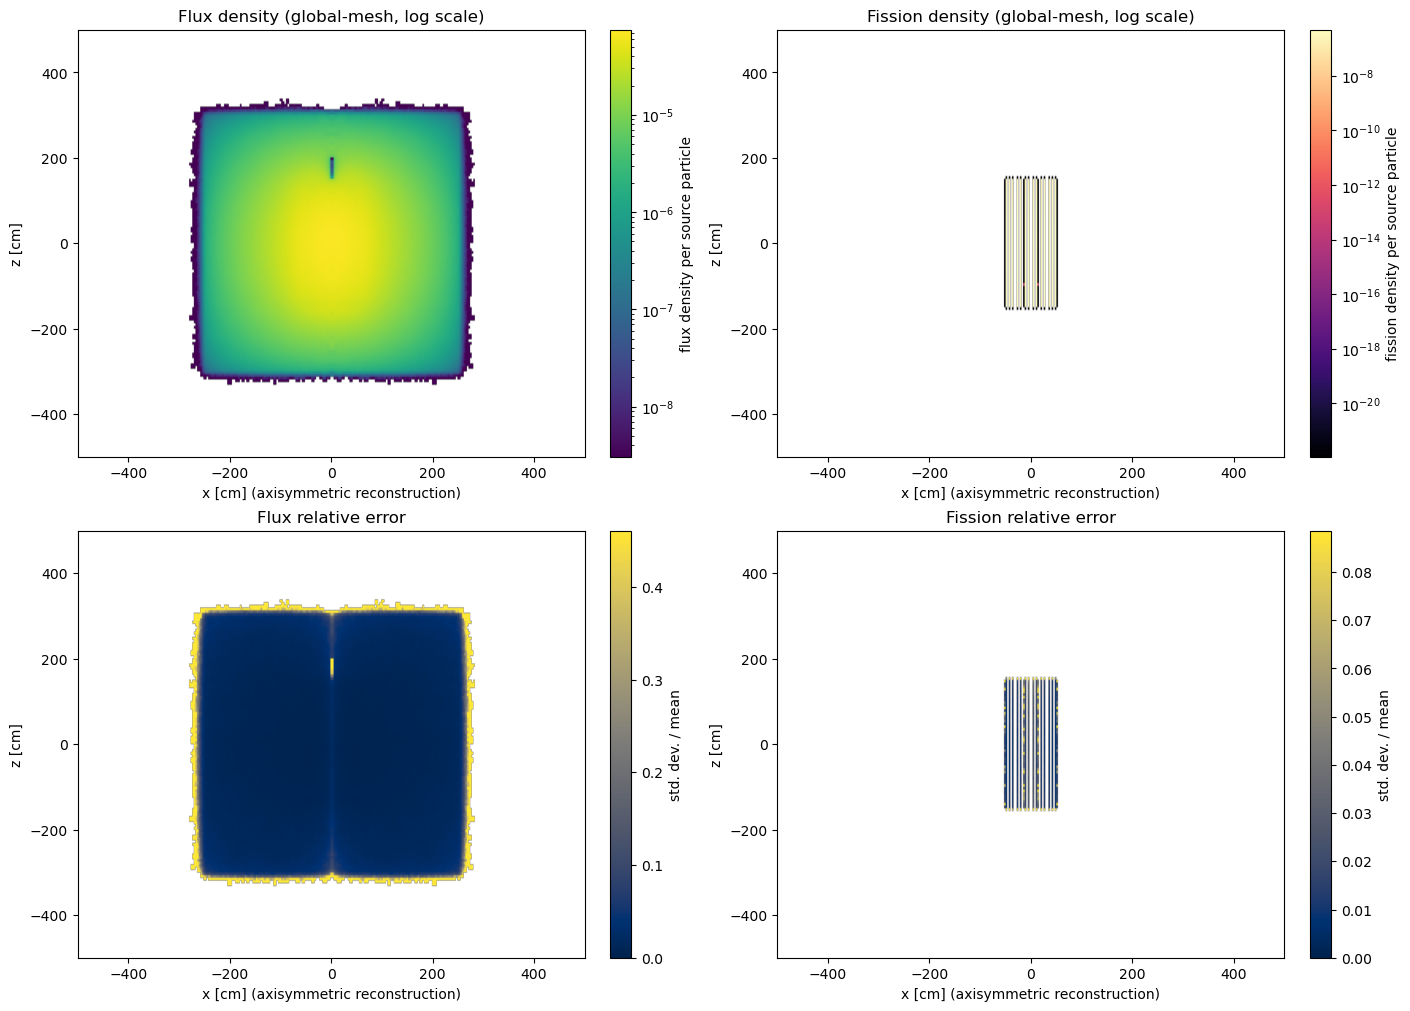

In [11]:
show_statepoint_diagnostics(
    statepoint_path,
    reference_metadata,
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
)

# Rod worth scan — OpenMC eigenvalue runs

Runs OpenMC at 11 insertion fractions (0 to 100%) to produce integral and differential
rod worth curves.  The absorber strength is controlled by `ROD_B10_FRACTION`:

- `3.8` = natural boron (default B4C)
- `8.0` = moderately enriched
- `19.9` = highly enriched B¹⁰ (maximum)

Mesh tallies are disabled for speed — this scan only needs k_eff.

In [4]:
# ── Rod absorber customization ─────────────────────────────────────────────
# Tune these to change the control rod absorption strength.
# Default B4C: B10=3.8, B11=0.2, C=1.0, density=2.52 g/cm³
ROD_B10_FRACTION = 0.001  # wt fraction of B¹⁰ (natural=3.8, enriched up to ~19.9)
ROD_DENSITY = 1.0       # g/cm³

_original_make_materials = fuel_element.make_default_materials

def _rod_scan_make_materials(parameters):
    """Material factory with tunable control-rod absorber strength."""
    materials, material_map = _original_make_materials(parameters)
    control_rod = openmc.Material(name="B4C control rod (custom)")
    control_rod.set_density("g/cm3", ROD_DENSITY)
    control_rod.add_nuclide("B10", ROD_B10_FRACTION)
    control_rod.add_element("C", 4.0)
    control_rod.temperature = 300.0
    material_map["control_rod"] = control_rod
    return openmc.Materials(
        [material_map["fuel"], material_map["moderator"], control_rod]
    ), material_map

# Patch both references so concentric_fuel also picks up the custom material
fuel_element.make_default_materials = _rod_scan_make_materials
concentric_fuel.make_shared_materials = _rod_scan_make_materials

# ── Rod worth scan ──────────────────────────────────────────────────────────
SCAN_PARTICLES = 100000
SCAN_BATCHES = 100
SCAN_INACTIVE = 10

cross_sections = openmc.config.get("cross_sections")
if cross_sections:
    ROD_SCAN_DIR = RUN_DIR / "rod_scan"
    ROD_SCAN_DIR.mkdir(parents=True, exist_ok=True)

    # Scan 0 → 100 % insertion
    x_arr = np.linspace(0.0, 1.0, 11)
    k_values = np.zeros_like(x_arr)
    rho_total = np.zeros_like(x_arr)

    for i, x_insert in enumerate(x_arr):
        print(f"Rod insertion x = {x_insert:.1f} …")
        model, _ = build_simulation.build_eigenvalue_model(
            CONCENTRIC_FUEL_PARAMETERS,
            REACTOR_TANK_PARAMETERS,
            rod_insertion=x_insert,
            particles=SCAN_PARTICLES,
            batches=SCAN_BATCHES,
            inactive=SCAN_INACTIVE,
            global_mesh_shape=None,
            fuel_mesh_shape=None,
        )
        sp_path = model.run(
            cwd=ROD_SCAN_DIR, threads=OPENMC_THREADS, openmc_exec=OPENMC_EXEC
        )

        with openmc.StatePoint(sp_path) as sp:
            k_values[i] = sp.keff.n
        rho_total[i] = (k_values[i] - 1.0) / k_values[i] * 1e5
        print(f"  k = {k_values[i]:.6f}   ρ = {rho_total[i]:+.1f} pcm")

    rho_ref = rho_total[0]  # use the first point as reference (unrodded core)
    delta_rho = rho_total - rho_ref  # rod worth relative to unrodded

    # Critical insertion (linear interpolation of zero-crossing)
    x_crit = None
    for j in range(len(x_arr) - 1):
        if rho_total[j] * rho_total[j + 1] <= 0:
            x_crit = x_arr[j] + (0.0 - rho_total[j]) * (
                x_arr[j + 1] - x_arr[j]
            ) / (rho_total[j + 1] - rho_total[j])
            break

    # ── Plots ───────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    ax1.plot(x_arr * 100, delta_rho, "o-", lw=2, ms=6, color="tab:blue",
             label="Δρ rod worth")
    ax1.plot(x_arr * 100, rho_total, "s--", lw=1.5, ms=4, color="tab:orange",
             label="ρ total")
    ax1.axhline(0, color="k", lw=0.5)
    ax1.set_xlabel("Rod insertion  [%]")
    ax1.set_ylabel("Reactivity  [pcm]")
    ax1.set_title(f"Integral reactivity  (B¹⁰ frac = {ROD_B10_FRACTION})")
    ax1.legend()

    drho = np.gradient(delta_rho, x_arr)
    ax2.plot(x_arr * 100, drho, "o-", lw=2, ms=6, color="tab:blue")
    ax2.axhline(0, color="k", lw=0.5)
    ax2.set_xlabel("Rod insertion  [%]")
    ax2.set_ylabel("dΔρ/dx  [pcm per unit insertion]")
    ax2.set_title("Differential worth")

    plt.suptitle("OpenMC rod worth scan  (concentric geometry)", fontsize=11)
    plt.tight_layout()
    plt.show()

    print()
    print(f"Clean-core excess reactivity: {rho_ref:+.1f} pcm")
    print(f"Full-insertion rod worth:    {delta_rho[-1]:+.1f} pcm")
    print(f"Full-insertion total ρ:      {rho_total[-1]:+.1f} pcm")
    if x_crit is not None:
        print(f"Critical insertion:          {x_crit * 100:.1f} %")
    else:
        print("Critical insertion:          not reached in [0, 1]")
else:
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before "
        "running rod-worth calculations."
    )

# # Restore original material factory
fuel_element.make_default_materials = _original_make_materials
concentric_fuel.make_shared_materials = _original_make_materials

Rod insertion x = 0.0 …
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
              

KeyboardInterrupt: 